***Stock EDA - VN HOSE (2012-02-06 - 2025-12-31) ***

prerequisite: run python -m src.data.processing.build_precessed to generate dataset

In [32]:
!pip  -q install statsmodels

In [33]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path

# Add project root so we can import src.*
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.eda.stats import describe_wide
from src.data.eda.stationarity import stationarity_summary
from src.data.eda.correlation import pearson_corr, pairwise_rolling
from src.data.eda.autocorr import acf_table
from src.data.eda.plots import (
    plot_prices, plot_return_distribution,
    plot_correlation_heatmap, plot_acf_pacf, plot_rolling_corr,
)

STOCK_CODES = ['FPT', 'VCB', 'VIC', 'VNM', 'HPG']
INDICES = ['VNINDEX', 'VN30']

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


1.Load processed dataset

In [7]:
wide = pd.read_csv(
    PROJECT_ROOT / 'data/processed/eda/eda_processed.csv',
    parse_dates=['trading_date'],
).set_index('trading_date')

close_cols = [f'{t}_close' for t in TICKERS] + [f'{i}_close' for i in INDICES]
ret_cols = [f'{t}_log_return' for t in TICKERS] + [f'{i}_log_return' for i in INDICES]

print(f'Shape: {wide.shape}, range: {wide.index.min().date()} -> {wide.index.max().date()}')
wide.head()

Shape: (3473, 28), range: 2012-02-06 -> 2025-12-31


,VCB_close,VCB_log_return,VCB_volume,VCB_volatility,FPT_close,FPT_log_return,FPT_volume,FPT_volatility,VIC_close,VIC_log_return,...,VNM_volume,VNM_volatility,VNINDEX_close,VNINDEX_log_return,VNINDEX_volume,VNINDEX_volatility,VN30_close,VN30_log_return,VN30_volume,VN30_volatility
trading_date,,,,,,,,,,,,,,,,,,,,,
2012-02-06,5.51,-0.007233,404650,0.009819,4.23,0.000000,40770,0.012794,9.84,0.034112,...,41690,0.003296,399.73,-0.005016,28639550,0.011254,447.47,NaN,13467070,0.0
2012-02-07,5.55,0.007233,502100,0.019550,4.23,0.000000,74910,0.012794,9.76,-0.008163,...,52570,0.003789,401.08,0.003372,32063940,0.009747,449.31,0.004104,17261070,0.0
2012-02-08,5.78,0.040606,801310,0.024386,4.31,0.018736,168150,0.011252,9.76,0.000000,...,38740,0.007085,409.53,0.020849,41644860,0.012186,460.98,0.025642,20406280,0.0
2012-02-09,5.71,-0.012185,410610,0.020747,4.35,0.009238,153780,0.011148,9.76,0.000000,...,88490,0.006538,411.39,0.004532,41021360,0.007903,464.73,0.008102,20379320,0.0
2012-02-10,5.57,-0.024824,924610,0.014908,4.31,-0.009238,195060,0.005548,9.67,-0.009264,...,58100,0.006538,405.02,-0.015605,45896610,0.009330,458.23,-0.014085,20816360,0.0


2.Descriptive statistics

In [8]:
describe_wide(wide, close_cols).round(4)

,count,mean,std,min,max,skew,kurtosis_excess,q01,q99
FPT_close,3473.0,32.5710,33.7960,3.54,131.67,1.3097,0.5349,3.8100,124.8876
VCB_close,3473.0,30.2379,19.4451,4.97,68.60,0.2855,-1.3471,5.6644,64.2224
VIC_close,3473.0,29.0376,20.8863,7.39,169.90,2.0001,7.8933,7.8772,107.7800
VNM_close,3473.0,56.3348,20.1829,12.72,102.22,-0.4464,-0.5484,13.0000,98.0440
HPG_close,3473.0,11.1756,8.8166,0.78,32.65,0.5964,-0.9971,0.8900,30.1800
VNINDEX_close,3473.0,912.8547,337.3559,375.26,1784.49,0.2630,-0.8956,388.5640,1683.4992
VN30_close,3473.0,933.1693,355.6729,441.49,2030.63,0.7068,-0.2326,455.0944,1919.5888


In [9]:
describe_wide(wide, ret_cols).round(4)
# Note: kurtosis_excess >> 0 indicates fat tails (typical for financial returns).

,count,mean,std,min,max,skew,kurtosis_excess,q01,q99
FPT_log_return,3473.0,0.0009,0.0162,-0.0726,0.0679,-0.0381,3.3220,-0.0483,0.0476
VCB_log_return,3473.0,0.0007,0.0180,-0.0726,0.0681,-0.0515,2.5040,-0.0533,0.0516
VIC_log_return,3473.0,0.0008,0.0190,-0.0727,0.0677,0.2356,3.4057,-0.0600,0.0664
VNM_log_return,3473.0,0.0004,0.0147,-0.0727,0.0678,0.1746,3.4098,-0.0399,0.0444
HPG_log_return,3473.0,0.0010,0.0210,-0.0736,0.0700,-0.0154,1.5475,-0.0621,0.0601
VNINDEX_log_return,3473.0,0.0004,0.0116,-0.0691,0.0655,-0.9081,4.7169,-0.0393,0.0283
VN30_log_return,3472.0,0.0004,0.0121,-0.0705,0.0667,-0.7921,4.4641,-0.0415,0.0303


Distribution of returns

In [24]:
%matplotlib inline

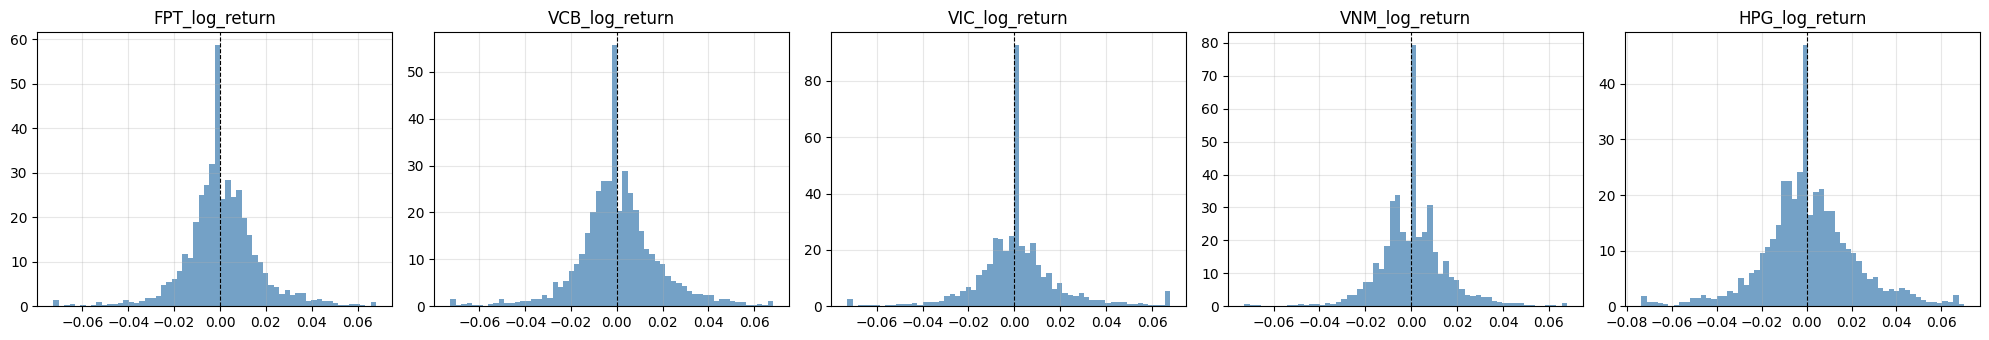

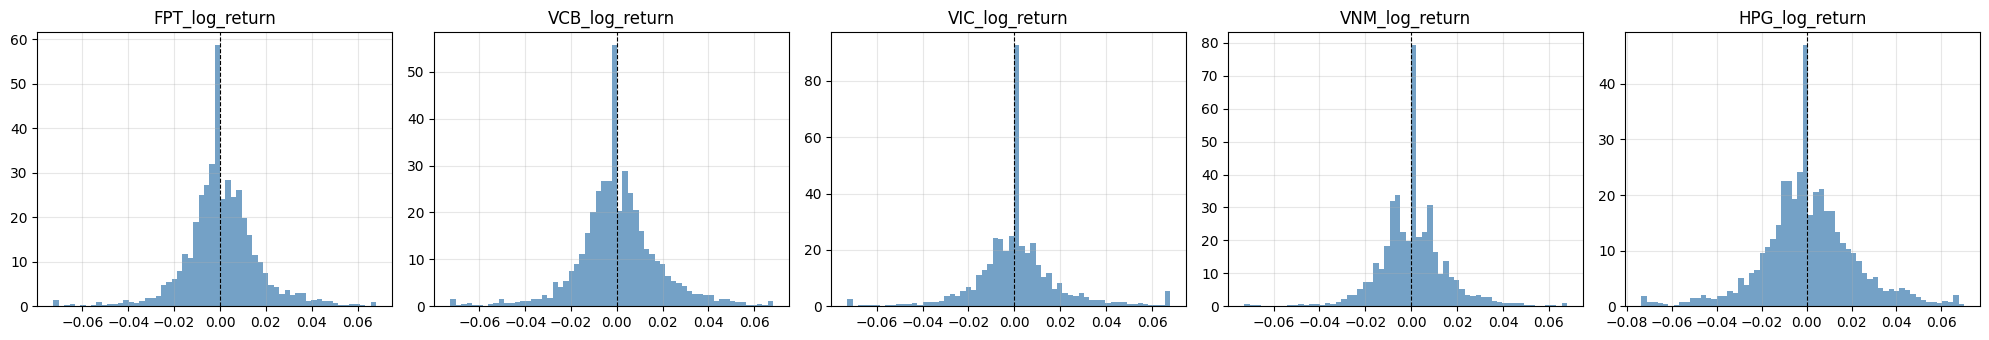

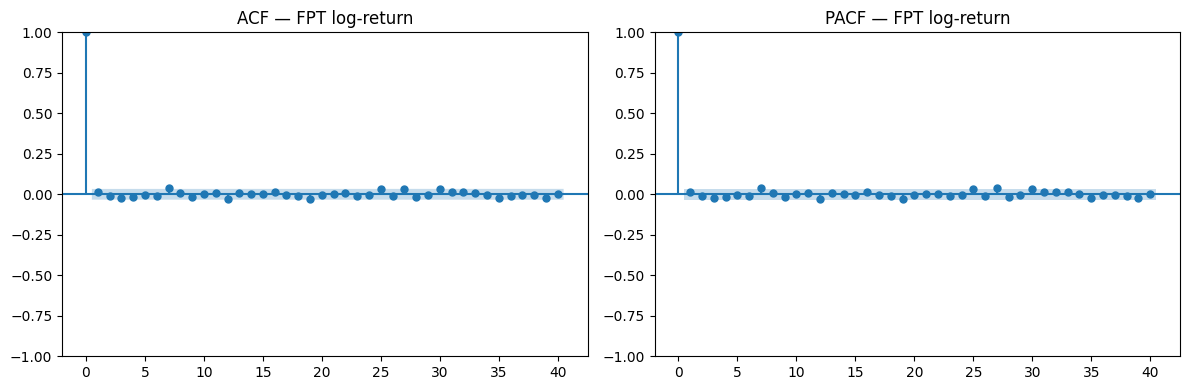

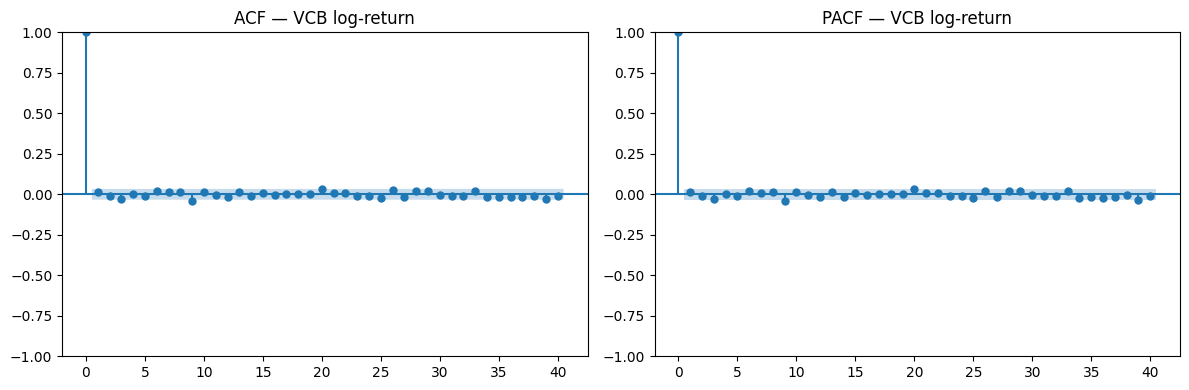

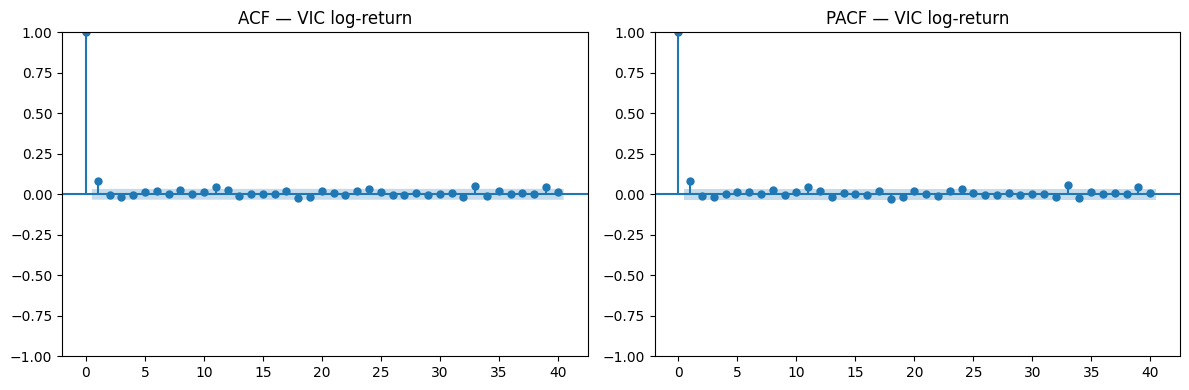

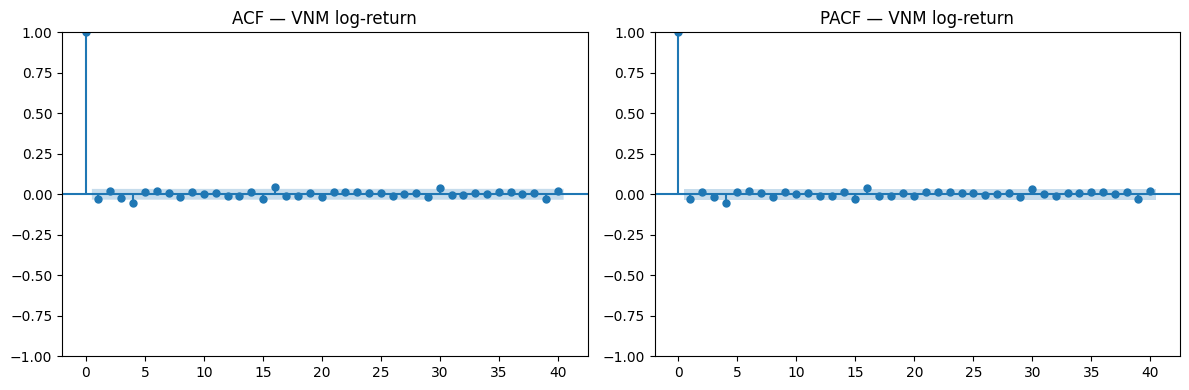

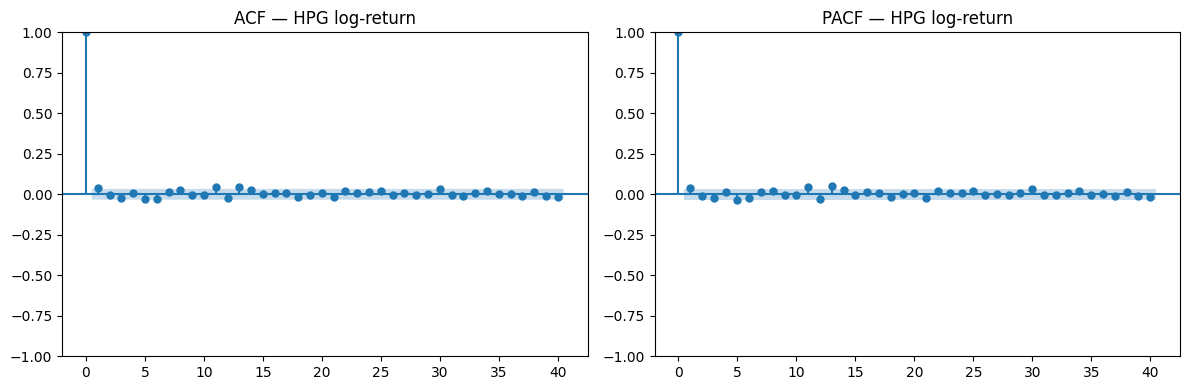

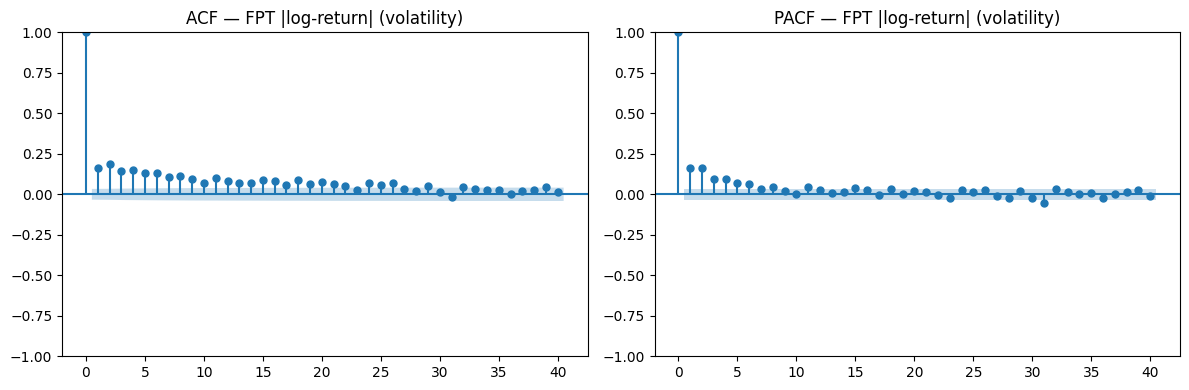

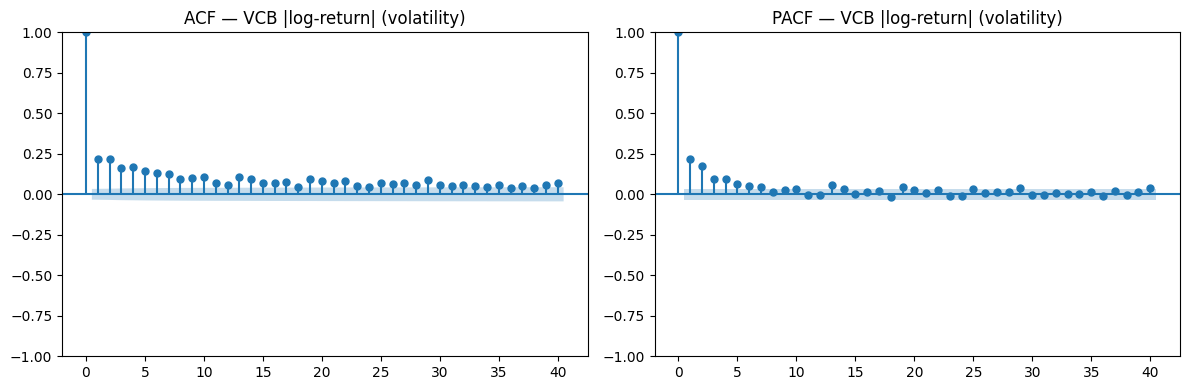

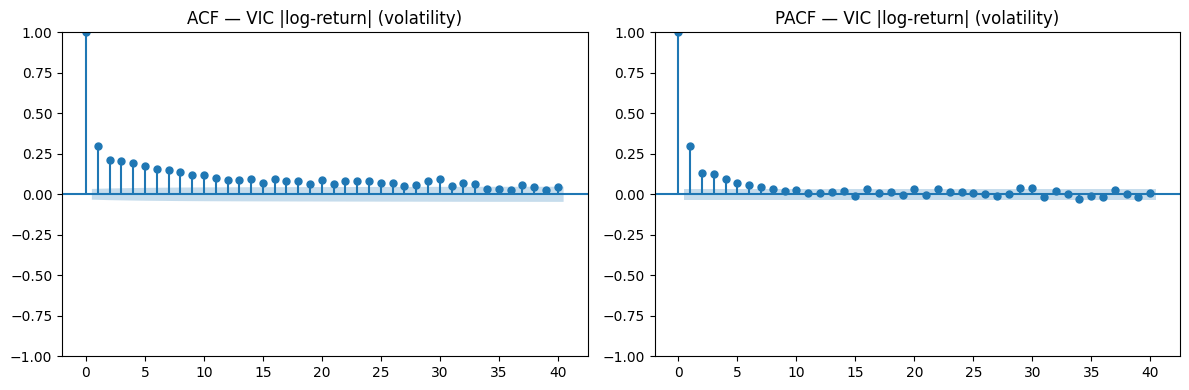

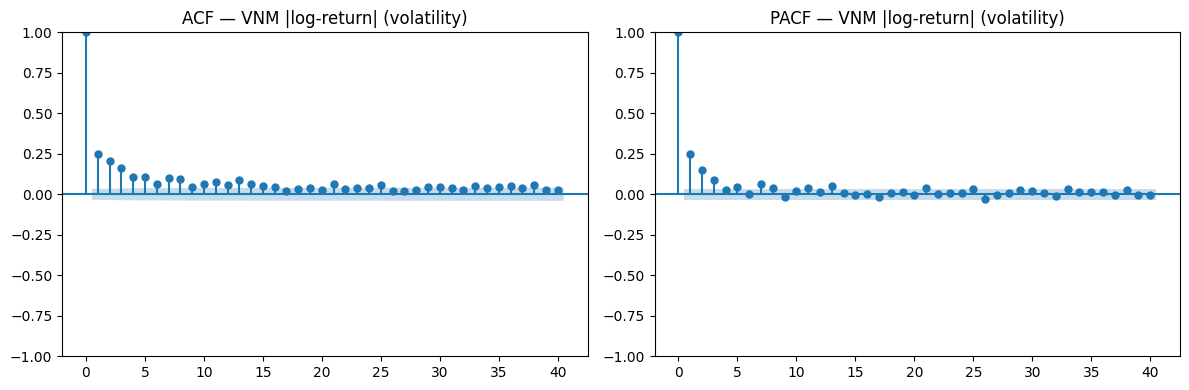

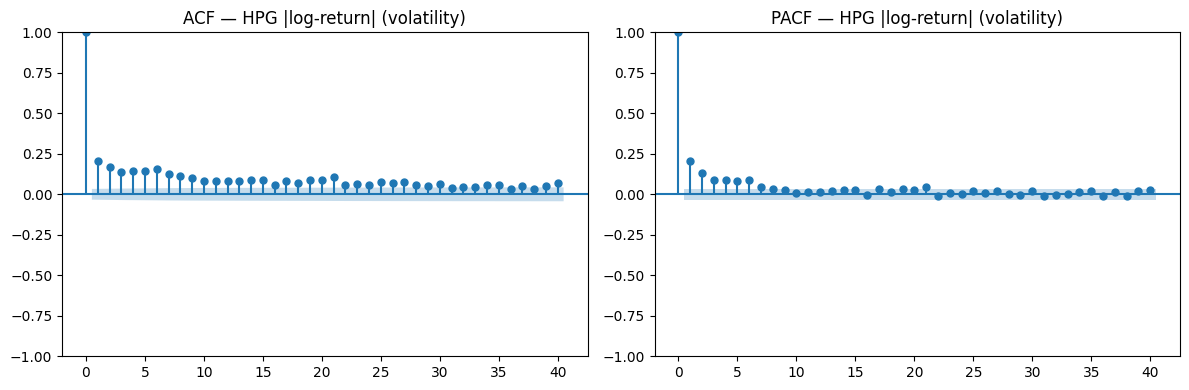

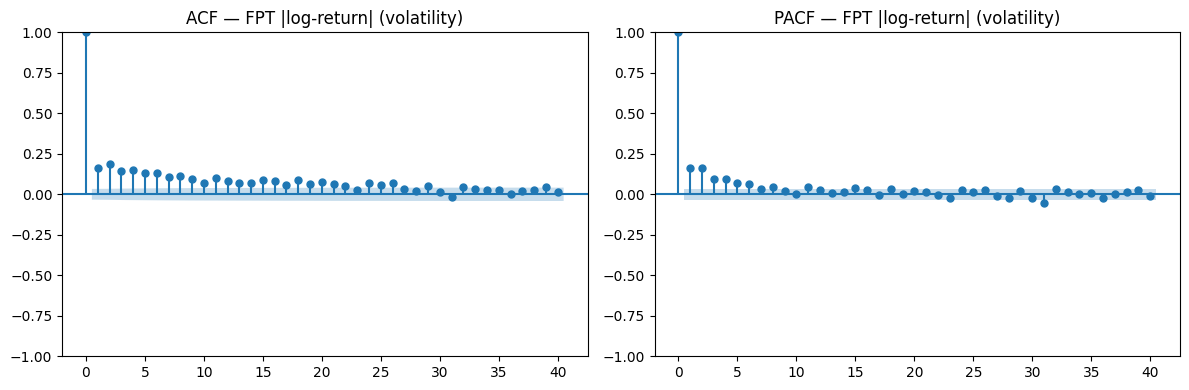

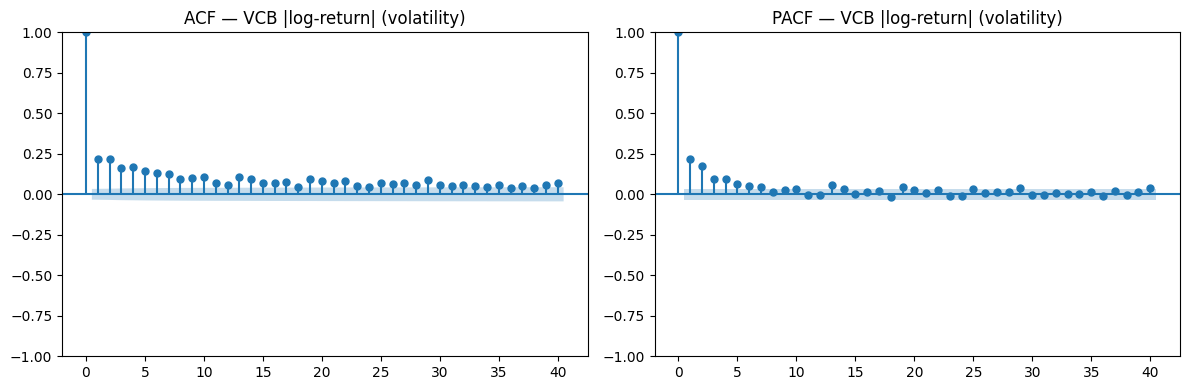

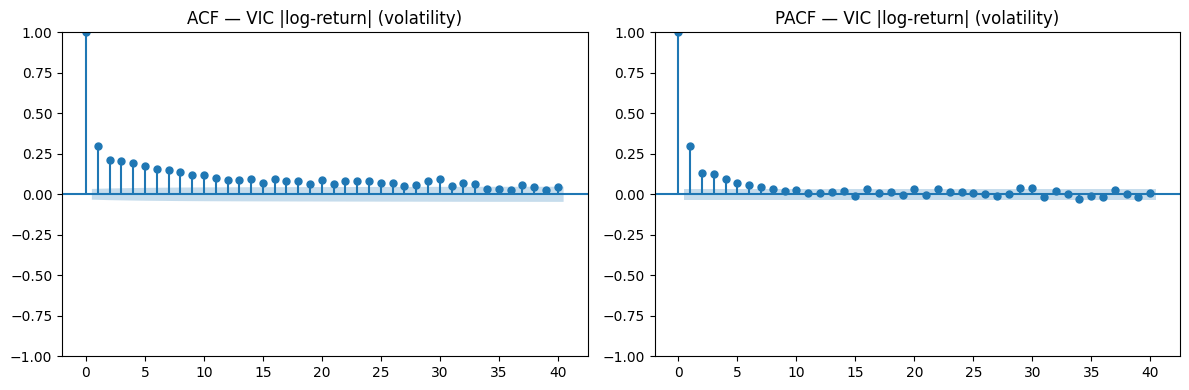

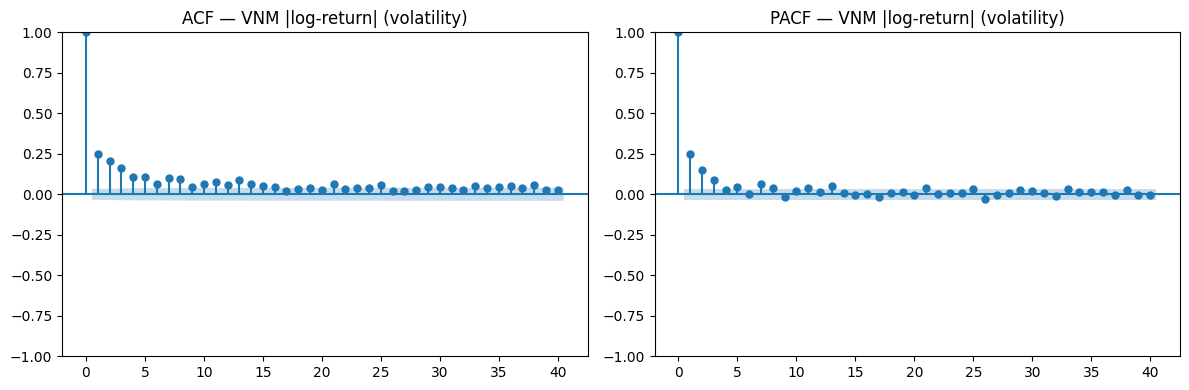

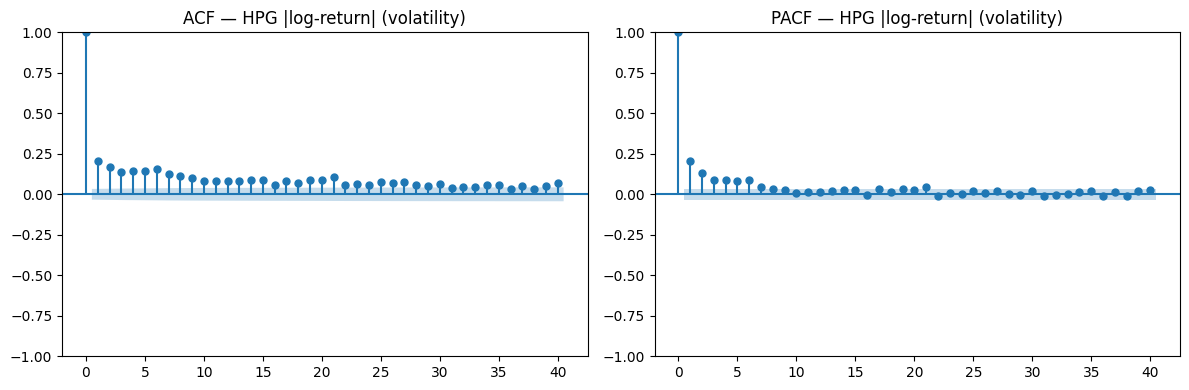

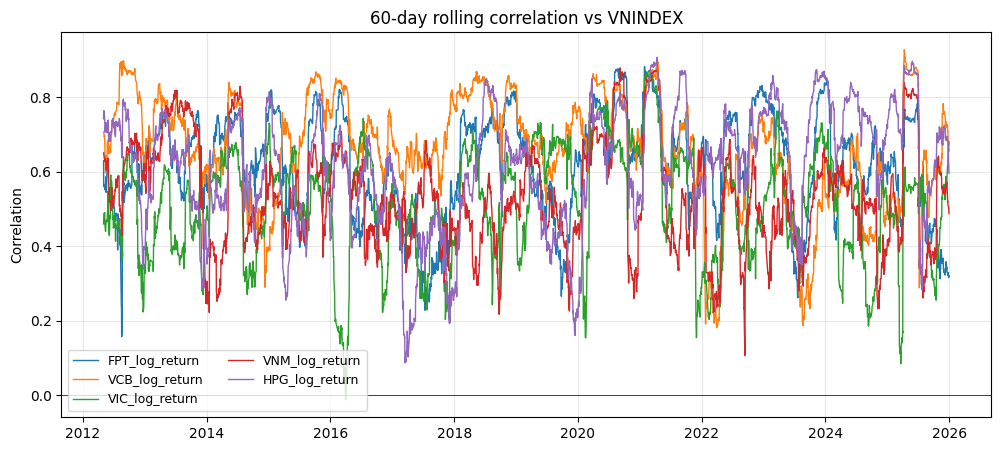

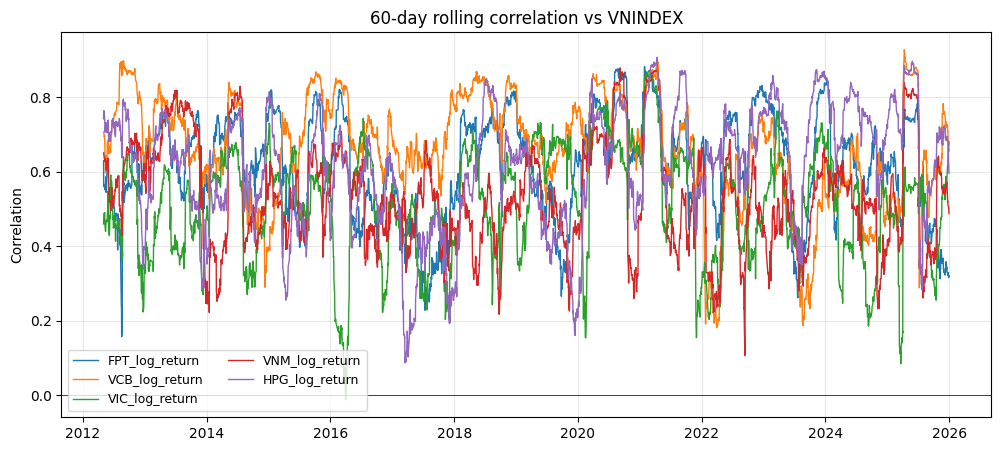

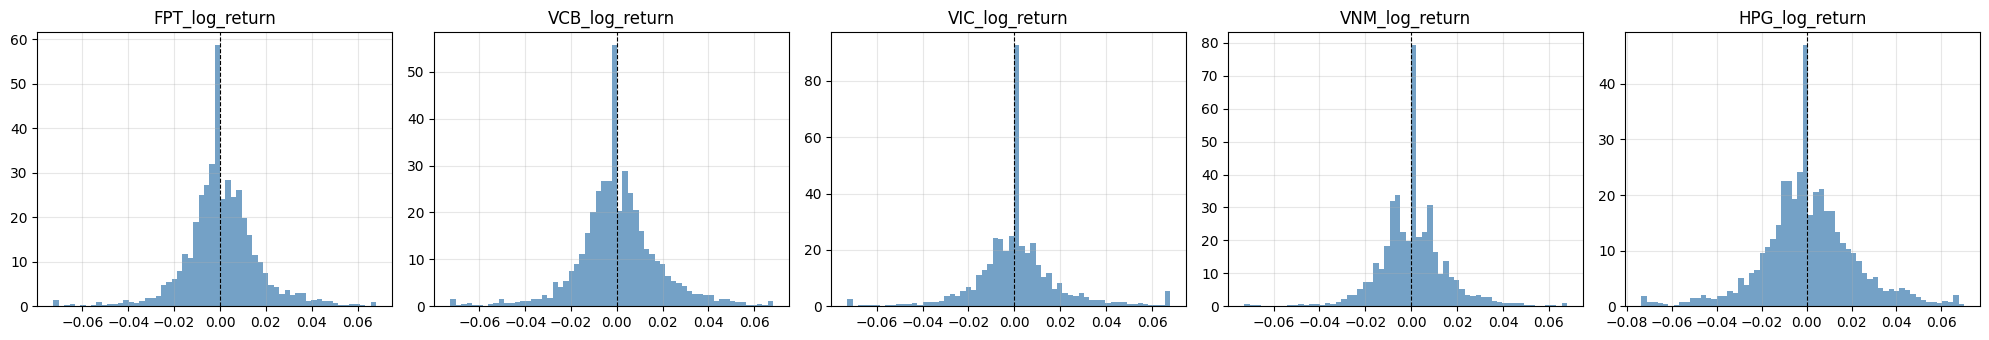

In [25]:
plot_return_distribution(wide.reset_index(), [f'{t}_log_return' for t in STOCK_CODES])

Stationary(ADF+KPSS) (close non-stationary, log_return stationary)


In [26]:
stationarity_summary(wide, close_cols)[['adf_pvalue', 'kpss_pvalue', 'verdict']]

KeyError: "['adf_pvalue', 'kpss_pvalue'] not in index"

In [30]:
stationarity_summary(wide, ret_cols)[['adf_stationary', 'kpss_stationary', 'verdict']]

,adf_stationary,kpss_stationary,verdict
series,,,
FPT_log_return,True,True,stationary
VCB_log_return,True,True,stationary
VIC_log_return,True,True,stationary
VNM_log_return,True,False,difference-stationary
HPG_log_return,True,True,stationary
VNINDEX_log_return,True,True,stationary
VN30_log_return,True,True,stationary


Correlation 

In [31]:
stationarity_summary(wide, close_cols)[['adf_stationary', 'kpss_stationary', 'verdict']]

,adf_stationary,kpss_stationary,verdict
series,,,
FPT_close,False,False,non-stationary
VCB_close,False,False,non-stationary
VIC_close,False,False,non-stationary
VNM_close,False,False,non-stationary
HPG_close,False,False,non-stationary
VNINDEX_close,False,False,non-stationary
VN30_close,False,False,non-stationary


ACF/PACF

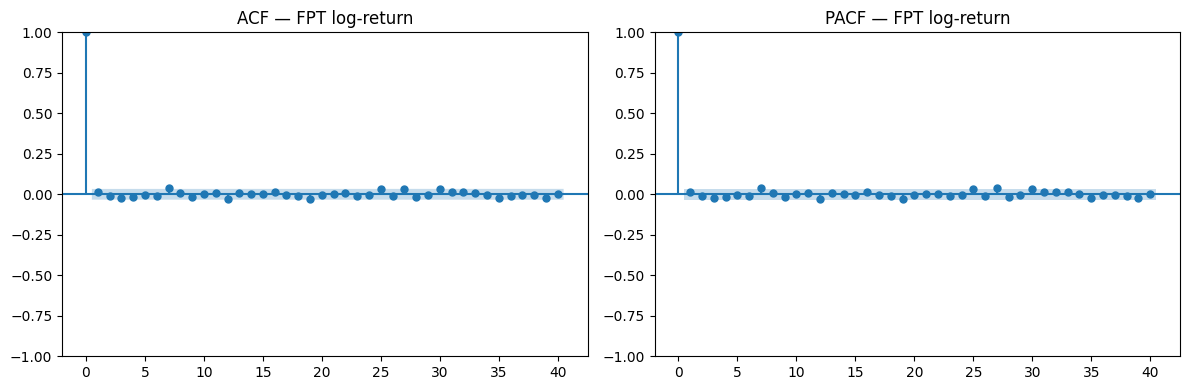

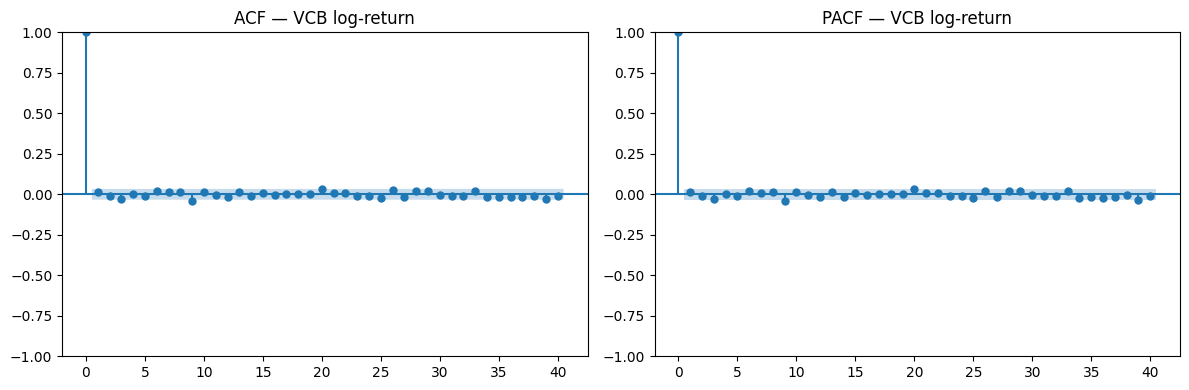

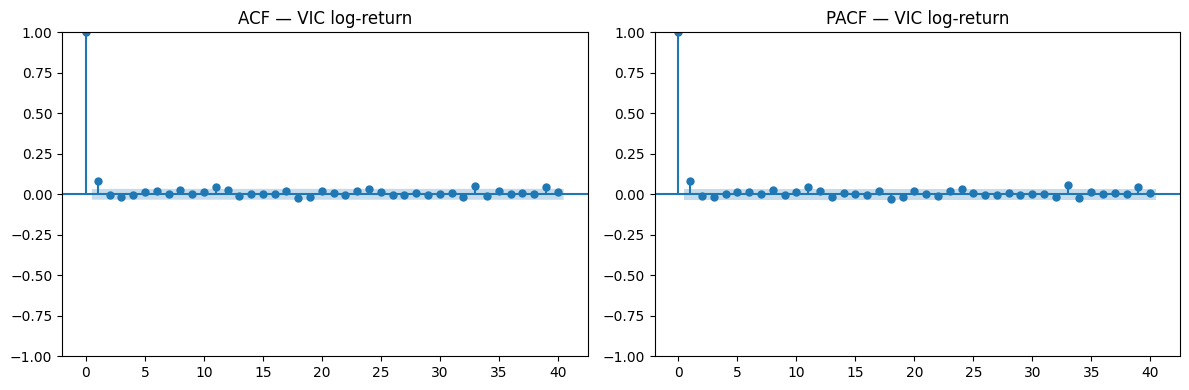

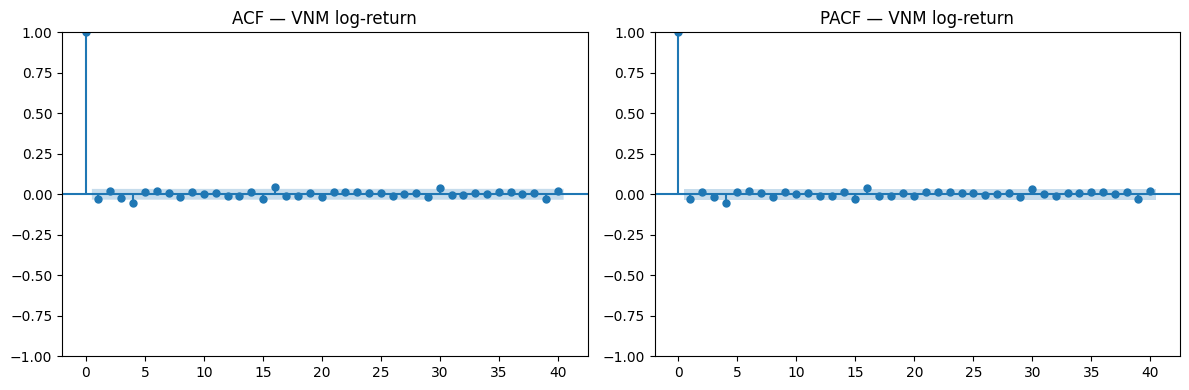

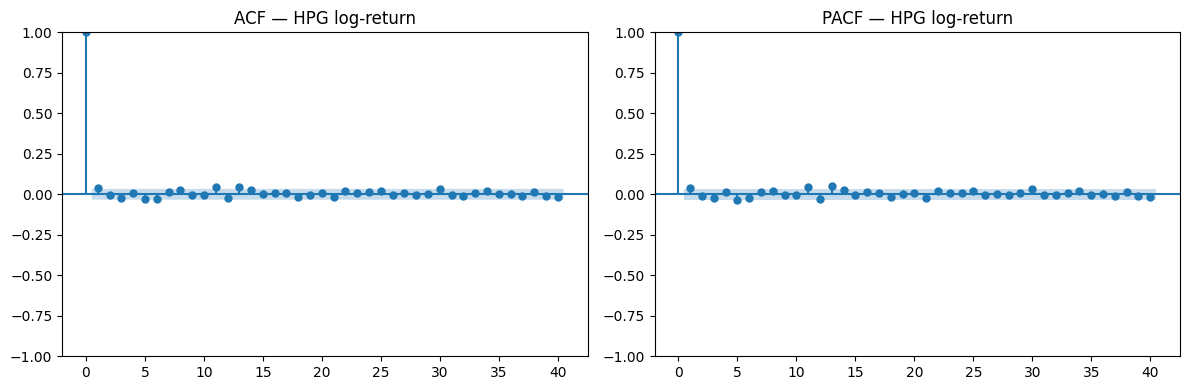

In [27]:
for t in STOCK_CODES:
    plot_acf_pacf(wide[f'{t}_log_return'], lags=40, title=f'{t} log-return')

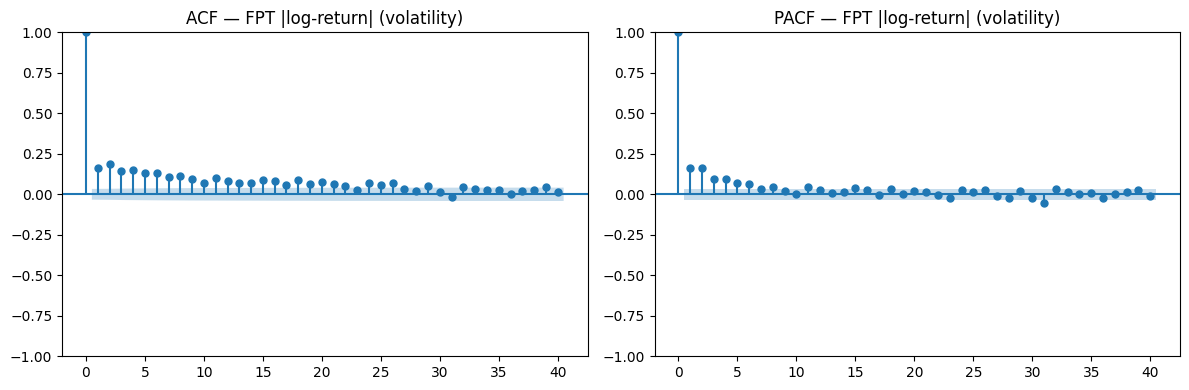

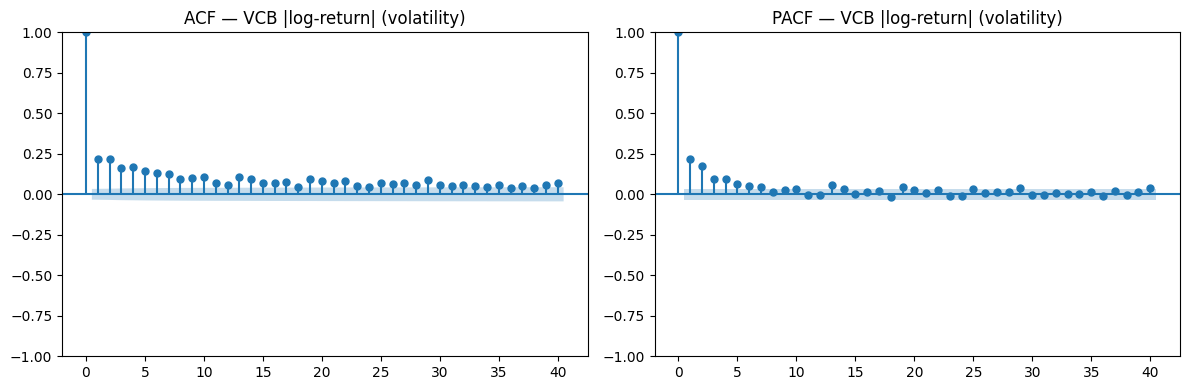

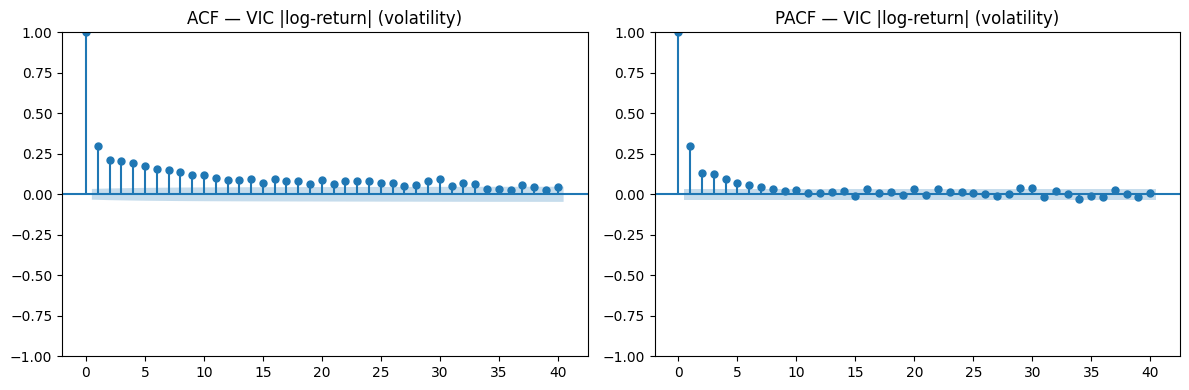

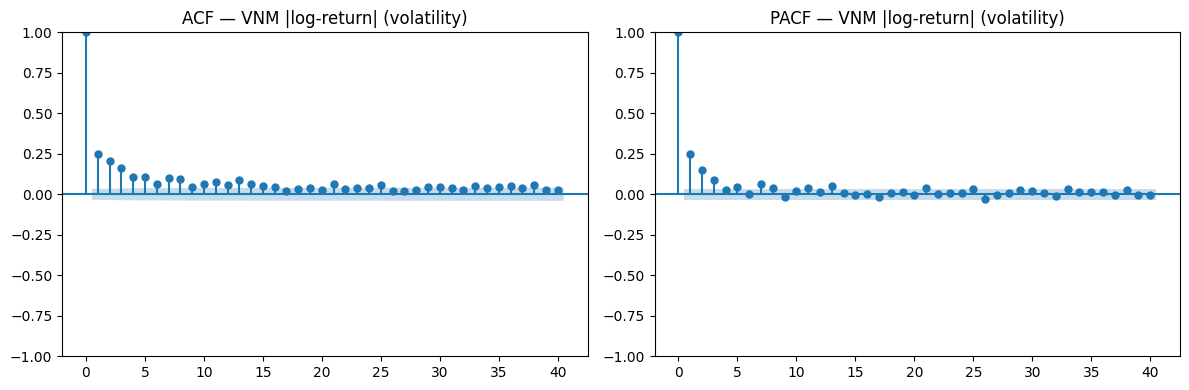

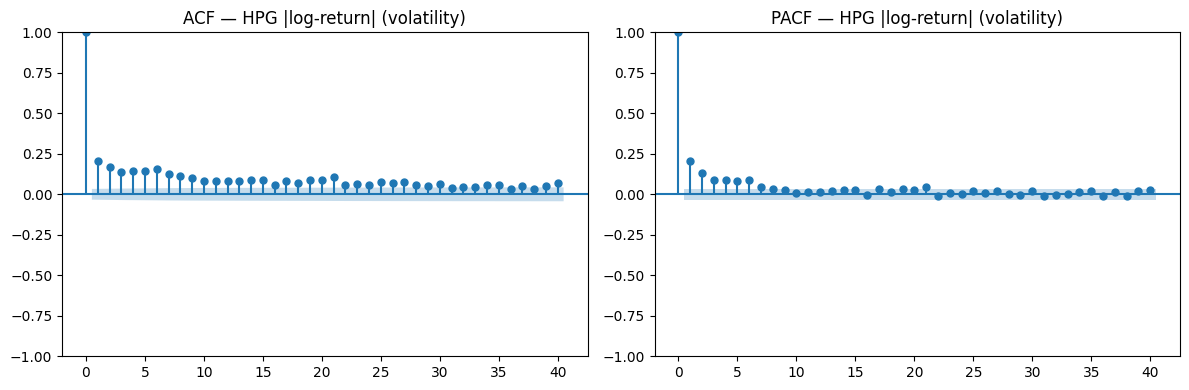

In [28]:
for t in STOCK_CODES:
    plot_acf_pacf(wide[f'{t}_log_return'].abs(), lags=40, title=f'{t} |log-return| (volatility)')

Rolling correlation 